In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [4]:
file_path = 'naruto.csv' 
df = pd.read_csv(file_path, encoding='ISO-8859-1')
print("\n--- Data Head ---")
print(df.head())
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Data Head ---
   Unnamed: 0  Num_episode                        Title                Type  \
0           1            1                   Homecoming  Mixed Canon/Filler   
1           2            2  The Akatsuki Makes Its Move  Mixed Canon/Filler   
2           3            3      The Results of Training  Mixed Canon/Filler   
3           4            4   The Jinchuriki of the Sand  Mixed Canon/Filler   
4           5            5     The Kazekage Stands Tall  Mixed Canon/Filler   

   Year_launch  Rate  Votes                Saga     Airdate  
0         2007   8.2    728  s1 Kazekage Rescue  2007-02-15  
1         2007   8.0    575  s1 Kazekage Rescue  2007-02-15  
2         2007   8.0    508  s1 Kazekage Rescue  2007-02-22  
3         2007   8.2    517  s1 Kazekage Rescue  2007-03-01  
4         2007   8.2    486  s1 Kazekage Rescue  2007-03-15  

--- Column Names ---
['Unnamed: 0', 'Num_episode', 'Title', 'Type', 'Year_launch', 'Rate', 'Votes', 'Saga', 'Airdate']

--- Missing V

In [7]:
df['Airdate'] = pd.to_datetime(df['Airdate'])
df['Year'] = df['Airdate'].dt.year
df['Month'] = df['Airdate'].dt.month
df['Popularity_Score'] = df['Rate'] * df['Votes']
df['Rate'] = df['Rate'].fillna(df['Rate'].median())
df['Votes'] = df['Votes'].fillna(0)

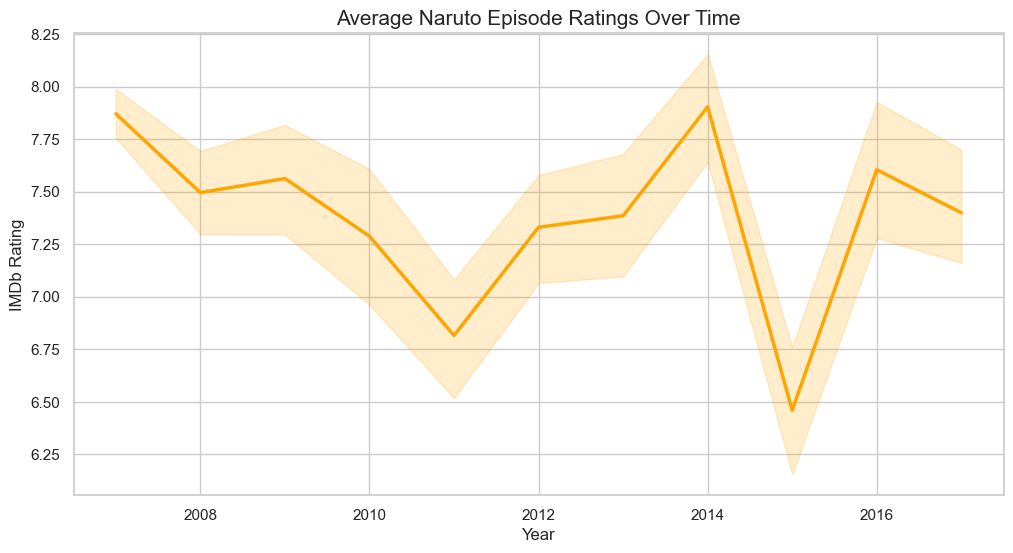

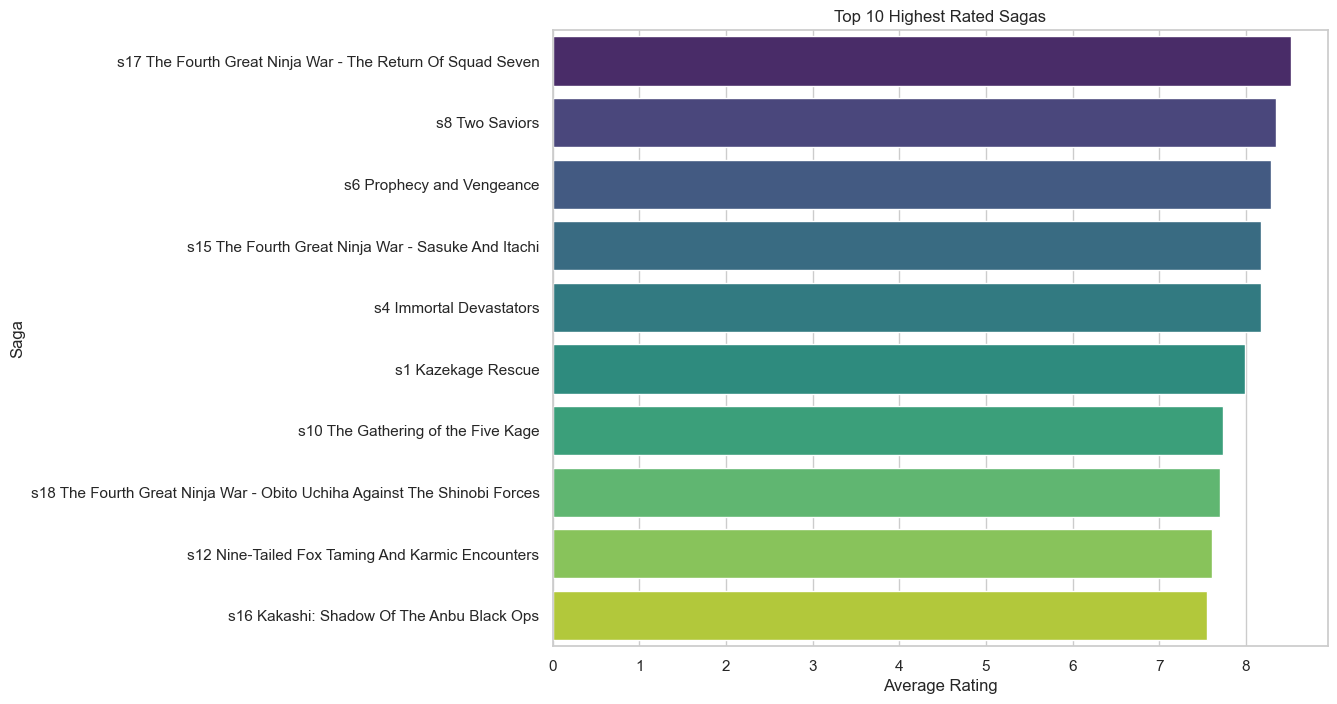

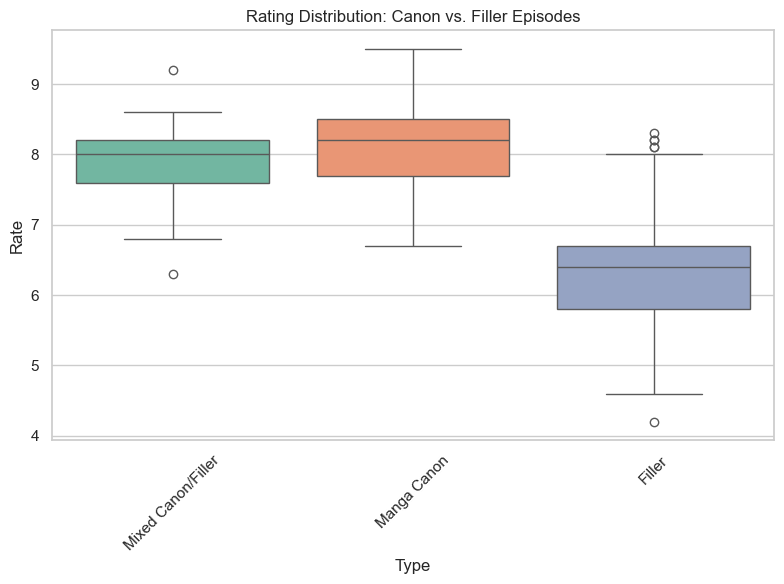

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Rate', estimator='mean', color='orange', linewidth=2.5)
plt.title('Average Naruto Episode Ratings Over Time', fontsize=15)
plt.ylabel('IMDb Rating')
plt.show()

plt.figure(figsize=(10, 8))
saga_rank = df.groupby('Saga')['Rate'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=saga_rank, x='Rate', y='Saga', hue='Saga', palette='viridis', legend=False)
plt.title('Top 10 Highest Rated Sagas')
plt.xlabel('Average Rating')
plt.savefig('top_sagas.png')


plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Type', y='Rate', hue='Type', palette='Set2', legend=False)
plt.title('Rating Distribution: Canon vs. Filler Episodes')
plt.xticks(rotation=45)
plt.tight_layout() # Ensures labels aren't cut off
plt.show()


In [9]:
le = LabelEncoder()
df['Type_Encoded'] = le.fit_transform(df['Type'])
df['Saga_Encoded'] = le.fit_transform(df['Saga'])

features = ['Type_Encoded', 'Saga_Encoded', 'Year', 'Votes']
X = df[features]
y = df['Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-Squared Score: {r2:.2f}")

# Show Feature Importance
# This tells you which factor (Year, Saga, etc.) affects the rating the most
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- What drives the Ratings? ---")
print(importances)


df.to_csv('final_naruto_episodes_analysis.csv', index=False)


--- Model Performance ---
Mean Absolute Error: 0.21
R-Squared Score: 0.88

--- What drives the Ratings? ---
Type_Encoded    0.478462
Votes           0.414028
Saga_Encoded    0.057780
Year            0.049729
dtype: float64


In [13]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid_search.fit(X_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}


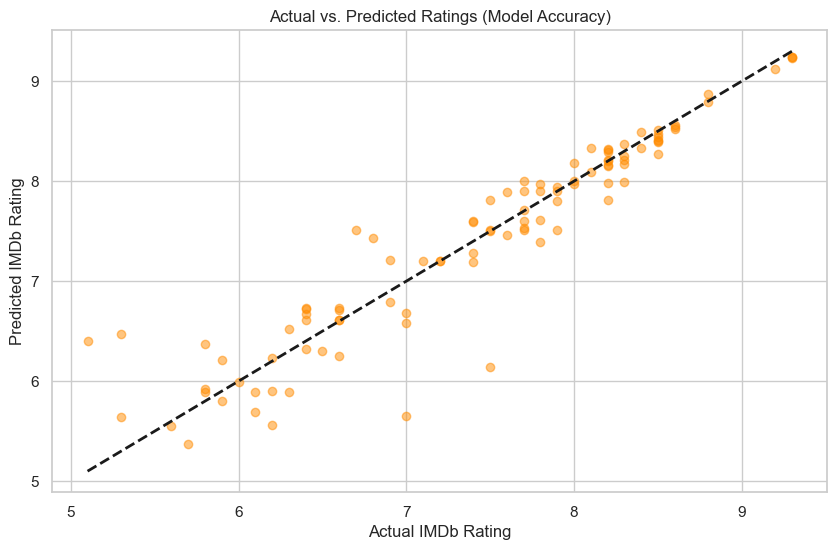

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs. Predicted Ratings (Model Accuracy)')
plt.xlabel('Actual IMDb Rating')
plt.ylabel('Predicted IMDb Rating')
plt.savefig('actual_vs_predicted.png')
plt.show()